# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Experiment Objective

The objective of this experiment is to establish a baseline model for predicting house prices using a dummy regressor.

## 1.3 Model Hypothesis

The Dummy Regressor is expected to achieve limited predictive performance because it ignores all feature imformation and predicts a constant value. The resulting performance metrics will serve as a baseline against which subsequent machine learning models can be compared.

# **2. Load Dataset**

In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
X_test = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Development**

## 3.1 Import Algorithm

In [3]:
# Import Dummy Regrssor module from sklearn
from sklearn.dummy import DummyRegressor

## 3.2 Train Model

In [4]:
# Fit Model
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


## 3.3 Generate Predictions

In [5]:
y_train_pred = baseline.predict(X_train)
y_val_pred = baseline.predict(X_val)
y_test_pred = baseline.predict(X_test)

# **4. Model Evaluation**

## 4.1 Technical Performance

In [6]:
# Import RMSE, RAE, R2 score from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [9]:
# Check the baseline performance
results = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RMSE': [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],
    'MAE': [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],
    'R2_Score': [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]    
})

results

,Dataset,RMSE,MAE,R2_Score
0,Train,0.401134,0.307029,0.000000
1,Validation,0.427087,0.333039,-0.014341
2,Test,0.438009,0.345882,-0.008766


## 4.2 Prediction Visualisation

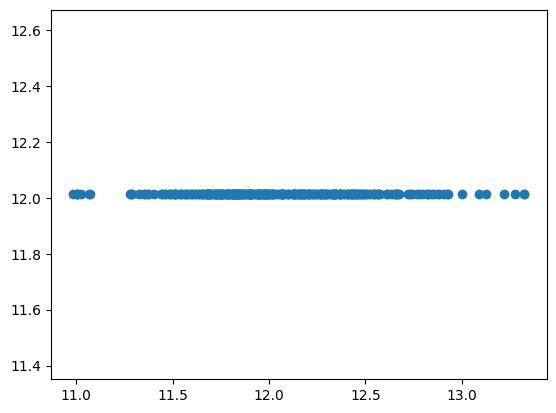

In [13]:
# Scatterplot of Actual Log SalePrice vs Predicted Log SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(y_test, y_test_pred)

## 4.3 Business Interpretation

- The Dummy Regressor achieved RMSE values between 0.40 and 0.44 across the training, validation, and test sets. The model produced an R2 score close to zero on the training set and slightly negative values on the validation and test sets.
- The scatter plot showed a horizontal prediction pattern because the model predicts the mean housing price for every observation. This indicates that the model does not learn any meaningful relationships between the features and SalePrice and serves only as a baseline for comparison with more advanced models.

# **5. Experiment Outcomes**

The Dummy Regressor achieved poor predictive performance as expected. Since the model ignores all feature information and predicts a constant value, it is unable to explain variations in housing prices. The near-zero and negative R2 values further confirm that the model does not capture meaningful relationships between property characteristics and SalePrice. Therefore, the Dummy Regressor serves only as a baseline for comparison and more advanced regression models will be explored in subsequent experiments.